<a href="https://colab.research.google.com/github/ryojifukagawa-pixel/wavelength-selective-film_vs_No_countermeasures_new/blob/main/wavelength_selective_film_vs_No_countermeasures_new.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

内部発熱量を想定して入力してください　デフォルト値＝50W/m2　数値のみでOK：50
内部発熱量 Q_INT = 50.0 [W/m2]

=== 比較結果 ===
                                                   定常室温[℃]  外気平均との差[℃]
No countermeasures                               35.060998    6.291357
wavelength-selective film                        20.451700   -8.317941
差(wavelength-selective film-No countermeasures) -14.609298  -14.609298


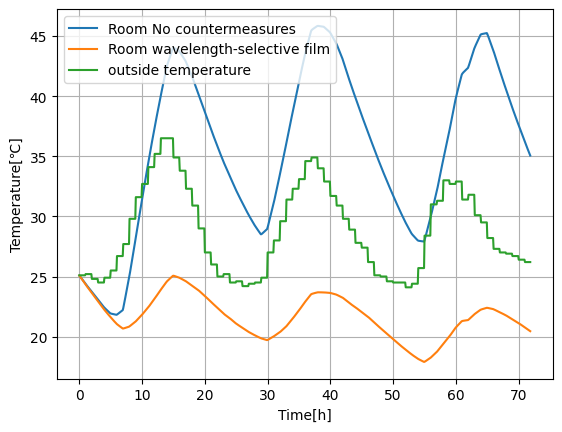

In [2]:
# ==============================================================
# 放射冷却 2質点モデル（屋根＋水＋内部発熱）
# wavelength-selective film vs 無対策 比較版
# ==============================================================
#
# ■■■ モデル物理構成 ■■■
#
#   天空
#     ↓ 長波放射
#   ┌───────────────┐
#   │ 屋根板（温度 T_r）│  ← 短波吸収・長波放射・対流
#   └───────────────┘
#            ↓ 伝熱 h_rw
#   ┌───────────────┐
#   │ 水層（温度 T_w） │  ← 室内熱容量代表
#   └───────────────┘
#            ↑ 内部発熱 Q_INT
#
# 室内温度 ≒ 水温 T_w と仮定
#
# ==============================================================
#
# ■■■ 暗黙の初期条件 ■■■
#
# T_r(0) = 外気温
# T_w(0) = 外気温
#
# ==============================================================
#
# ■■■ 定数・物性値 ■■■
#
# sigma      : Stefan-Boltzmann定数 [W/m2K4]
# beta       : 屋根傾斜角 [rad]
# F_sky      : 天空形態係数
# conv       : HASP日射単位変換係数
#
# C_r        : 屋根面積熱容量 [J/m2K]
# C_w        : 水面積熱容量 [J/m2K]
# h_rw       : 屋根-水間熱伝達率 [W/m2K]
#
# rho_sw     : 短波反射率 [-]
# epsilon    : 長波放射率 [-]
#
# Q_INT      : 室内内部発熱 [W/m2]
#
# dt         : 時間刻み [s]
#
# ==============================================================
#
# ■■■ 入力変数（気象データ） ■■■
#
# Ta         : 外気温 [K]
# Ib         : 法線面直達日射 [W/m2]
# Id         : 水平面天空日射 [W/m2]
# N          : 夜間放射量 [W/m2]
# V          : 風速 [m/s]
#
# ==============================================================
#
# ■■■ 計算変数 ■■■
#
# T_r        : 屋根温度 [K]
# T_w        : 水温（室温代表）[K]
#
# L_down     : 下向き長波放射 [W/m2]
# hc         : 外表面対流熱伝達率 [W/m2K]
# q_solar    : 屋根入射短波放射 [W/m2]
# q_sw       : 屋根吸収短波放射 [W/m2]
#
# Fr, Fw     : 非線形残差関数
# dTr, dTw   : ニュートン更新量
#
# ==============================================================
#
# ■■■ エネルギー収支式 ■■■
#
# 屋根：
# C_r dT_r/dt =
#     q_sw
#   + F_sky ε (L_down ? σT_r^4)
#   + hc (Ta ? T_r)
#   ? h_rw (T_r ? T_w)
#
# 水：
# C_w dT_w/dt =
#     h_rw (T_r ? T_w)
#   + Q_INT
#
# ==============================================================
#
# ■■■ 出力値 ■■■
#
# SteadyRoom : 最終時刻水温（定常室温）[℃]
# MeanTa     : 期間平均外気温 [℃]
# 外気平均との差 : 定常室温 ? 平均外気温 [K]
#
# ==============================================================

import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------
# 内部発熱 input
# -----------------------------
user_input = input("内部発熱量を想定して入力してください　デフォルト値＝50W/m2　数値のみでOK：")
if user_input.strip() == "":
    Q_INT = 50.0
else:
    Q_INT = float(user_input)

print("内部発熱量 Q_INT =", Q_INT, "[W/m2]")

sigma=5.670374e-8
beta=np.deg2rad(26.6)
F_sky=(1+np.cos(beta))/2
conv=0.01e6/3600

C_r = 5000.0
C_w = 311866.0
h_rw = 8.0

# ============================
# Embedded weather data
# ============================
weather_text = """
751752748745749755767777798816827841852865865849838823809790770760750752 0 72421
181180181179178183184188192189188187183194191196197197187184180175172170 0 72422
  0  0  0  0  0  0  0459607633647650640626344  0  0  0  0  0  0  0  0  0 0 72423
  0  0  0  0 14 72136124112117119117117115167172105 45  2  0  0  0  0  0 0 72424
 30 31 29 27 27 25 27 44 50 51 52 55 57 54 45 26 27 28 30 29 31 32 32 36 0 72425
  0  0  0  0  9 10 15 16 16  2  3  3  4  5 13  5  6  6  5  0  3  3 15 13 0 72426
  0  0  0  0 11 11 11 11 11 21 11 11 11 21 11 32 21 21 11  0 32 21 11 11 0 72427
745746742744745749770780796814823831846849840829817809798789778774762751 0 72531
172170171169170180181186188182181174182183187178179177184178173173172171 0 72532
  0  0  0  0  0167497569609636647652521  0  0  0  0  0  0  0  0  0  0  0 0 72533
  0  0  0  0 14 76 86103112115119117153287232170105 43  2  0  0  0  0  0 0 72534
 34 37 38 39 39 39 52 50 52 54 55 57 51 29 28 29 30 28 26 29 28 28 26 28 0 72535
 14 14 10  0  0  0 15  0  2  3  1  2  3  6  4  6  5  6  4  4  2  5  3  3 0 72536
 21 11 11  0  0  0 11  0 11 11 21 11 21 21 21 21 21 21 11 11 11 11 11 21 0 72537
750746745745741744757784810813830827829814818801795782773770769767764762 0 72641
169171173172172176180182188186192188189184182175173173175175177176177178 0 72642
  0  0  0  0  0  0  0330339507459650456  5461428229  0  0  0  0  0  0  0 0 72643
  0  0  0  0 14 67129153182153174117172308139115100 41  2  0  0  0  0  0 0 72644
 27 28 27 27 27 27 26 40 40 47 44 52 44 30 47 50 44 42 39 38 35 34 32 31 0 72645
  4  4  3  3  5  3  6  6  9  9  9  9  9  8  9  9  9  9  9  9  9  9 10 10 0 72646
 11 11 11 11 11 11 11 11 21 21 32 32 32 42 32 42 53 32 32 32 32 21 11 11 0 72647
"""




#rows=[]
#with open("abiko_0724-0726.txt") as f:
#    for line in f:
#        fixed=line[:72]
#        rows.append([float(fixed[h*3:(h+1)*3]) for h in range(24)])

rows=[]
for line in weather_text.strip().split("\n"):
    fixed=line[:72]
    rows.append([float(fixed[h*3:(h+1)*3]) for h in range(24)])


data=np.array(rows)

days=3
rows_per_day=7
Ta_raw=[]; Ib_raw=[]; Id_raw=[]; wind_raw=[]; rad_raw=[]

for d in range(days):
    base=d*rows_per_day
    Ta_raw.extend(data[base])
    rad_raw.extend(data[base+1])
    Ib_raw.extend(data[base+2])
    Id_raw.extend(data[base+3])
    wind_raw.extend(data[base+4])

Ta=(np.array(Ta_raw)*0.1-50)+273.15
Ib=np.array(Ib_raw)*conv
Id=np.array(Id_raw)*conv
N=np.array(rad_raw)*conv
V=np.array(wind_raw)*0.1

dt=300
steps=int(3600/dt)

Ta=np.repeat(Ta,steps)
Ib=np.repeat(Ib,steps)
Id=np.repeat(Id,steps)
N=np.repeat(N,steps)
V=np.repeat(V,steps)

cases={
"No countermeasures": {"rho":0.20,"eps":0.90},
"wavelength-selective film": {"rho":0.92,"eps":0.94}
}

results={}

for case_name,prop in cases.items():

    rho_sw=prop["rho"]
    epsilon=prop["eps"]

    T_r=Ta[0]
    T_w=Ta[0]

    Tr_hist=[]
    Tw_hist=[]
    Ta_hist=[]

    for i in range(len(Ta)-1):

        Ta_i=Ta[i]
        L_down=sigma*Ta_i**4 - N[i]
        hc=5.7+3.8*V[i]

        q_solar=Ib[i]*np.cos(beta)+Id[i]*F_sky
        q_sw=(1-rho_sw)*q_solar

        def f_roof(T_r_new,T_w_new):
            return (q_sw
                    +F_sky*epsilon*(L_down-sigma*T_r_new**4)
                    +hc*(Ta_i-T_r_new)
                    -h_rw*(T_r_new-T_w_new))

        def f_water(T_r_new,T_w_new):
            return (h_rw*(T_r_new-T_w_new)
                    +Q_INT)

        T_r_new=T_r
        T_w_new=T_w

        for _ in range(15):

            Fr = T_r_new - T_r - dt/C_r*f_roof(T_r_new,T_w_new)
            Fw = T_w_new - T_w - dt/C_w*f_water(T_r_new,T_w_new)

            dFr_dTr = 1 - dt/C_r*(
                -F_sky*epsilon*(4*sigma*T_r_new**3)
                -hc
                -h_rw
            )
            dFr_dTw = -dt/C_r*(h_rw)
            dFw_dTr = -dt/C_w*(h_rw)
            dFw_dTw = 1 - dt/C_w*(-h_rw)

            det = dFr_dTr*dFw_dTw - dFr_dTw*dFw_dTr

            dTr = (-Fr*dFw_dTw - (-Fw)*dFr_dTw)/det
            dTw = (dFr_dTr*(-Fw) - dFw_dTr*(-Fr))/det

            T_r_new+=dTr
            T_w_new+=dTw

            if abs(dTr)<1e-4 and abs(dTw)<1e-4:
                break

        T_r=T_r_new
        T_w=T_w_new

        Tr_hist.append(T_r-273.15)
        Tw_hist.append(T_w-273.15)
        Ta_hist.append(Ta_i-273.15)

    results[case_name]={
        "Roof":Tr_hist,
        "Room":Tw_hist,
        "Ta":Ta_hist,
        "SteadyRoom":Tw_hist[-1],
        "MeanTa":np.mean(Ta_hist)
    }

summary=pd.DataFrame(index=cases.keys())

for case in cases:
    summary.loc[case,"定常室温[℃]"]=results[case]["SteadyRoom"]
    summary.loc[case,"外気平均との差[℃]"]=results[case]["SteadyRoom"]-results[case]["MeanTa"]

#summary.loc["差(wavelength-selective film-No countermeasures)"]=summary.loc["wavelength-selective film"]-summary.loc["No countermeasures"]
summary.loc["差(wavelength-selective film-No countermeasures)"]=summary.loc["wavelength-selective film"]-summary.loc["No countermeasures"]

print("\n=== 比較結果 ===")
print(summary)

time=np.arange(len(results["No countermeasures"]["Room"]))*dt/3600

plt.figure()
plt.plot(time,results["No countermeasures"]["Room"],label="Room No countermeasures")
plt.plot(time,results["wavelength-selective film"]["Room"],label="Room wavelength-selective film")
plt.plot(time,results["No countermeasures"]["Ta"],label="outside temperature")
plt.legend()
plt.xlabel("Time[h]")
plt.ylabel("Temperature[℃]")
plt.grid()
plt.show()